In [1]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install scikit-learn xgboost imbalanced-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.5 MB/s eta 0:00:41
   ---------------------------------------- 1.0/101.7 MB 2.2 MB/s eta 0:00:46
    --------------------------------------- 1.6/101.7 MB 2.4 MB/s eta 0:00:43
    --------------------------------------- 2.1/101.7 MB 2.3 MB/s eta 0:00:44
    --------------------------------------- 2.4/101.7 MB 2.3 MB/s eta 0:00:44
   - -------------------------------------- 2.9/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 3.7/101.7 MB 2.5 MB/s eta 0:00:40
   - -------------------------------------- 4.5/101.7 MB 2.5 MB/s eta 0:00:39
   - -------------------------------------- 5.0/101.7 MB 2.6 MB/s eta 0:00:37
   -- ------------------------------------- 5.8/101.7 MB 2.7 MB/s eta 0:00:36
   -- -


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import all the required libraries
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc 
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE 
print("Successfully imported")

Successfully imported


In [3]:
# load and Explore Data
data_set = pd.read_csv('fraud_detection.csv')

# first look of the dataset
print(data_set.head())
print(data_set.shape)
data_set.info()  # tells about the datatypes and non-null counts
print(data_set.describe())  # gives the statistical summary (mean,median,max,min)

# check null or missing values
print(data_set.isnull().sum())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0             0.0        0  
1  M2044282225             0.0             0.0        0  
2   C553264065             0.0             0.0        1  
3    C38997010         21182.0             0.0        1  
4  M1230701703             0.0             0.0        0  
(6362620, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step       

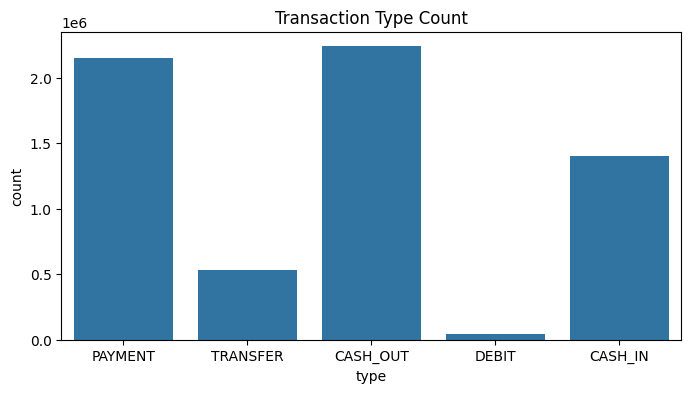

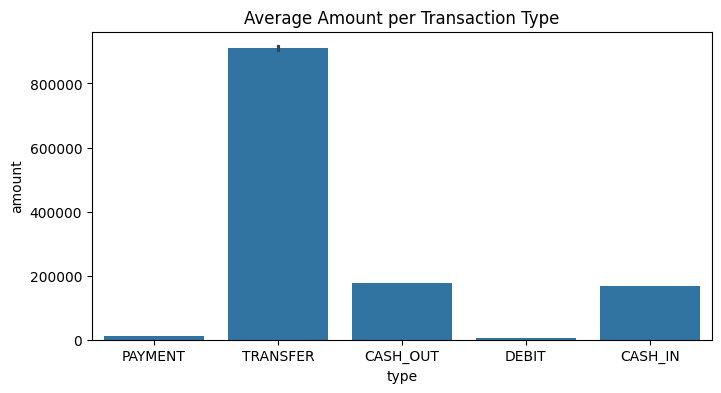

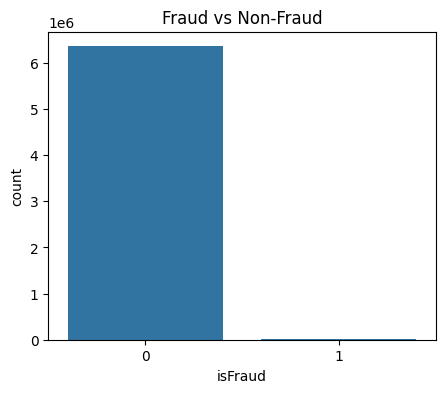

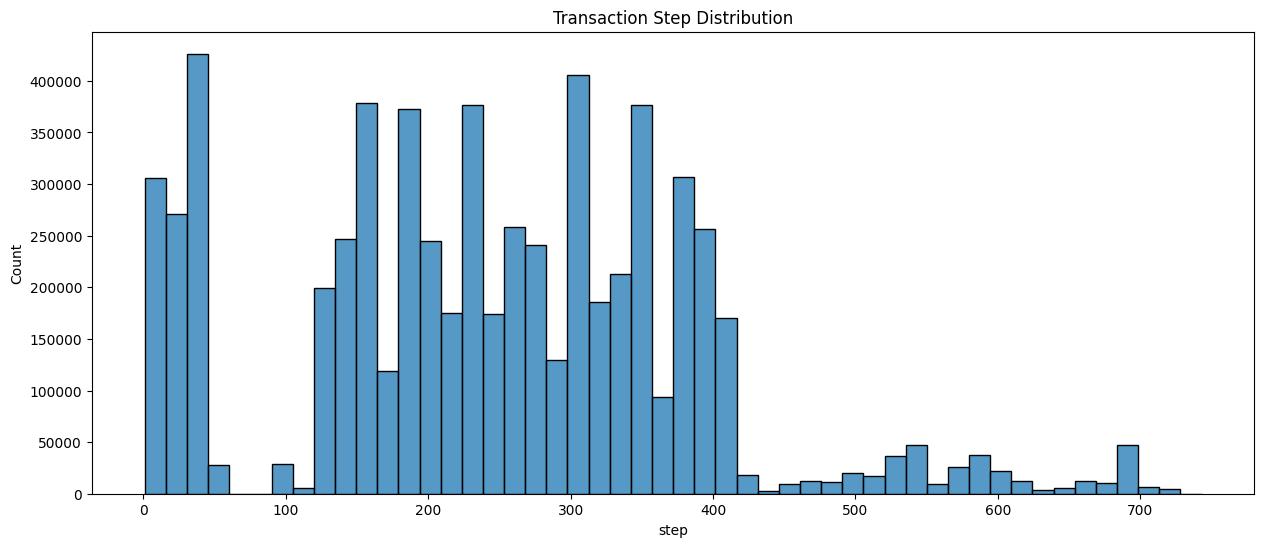

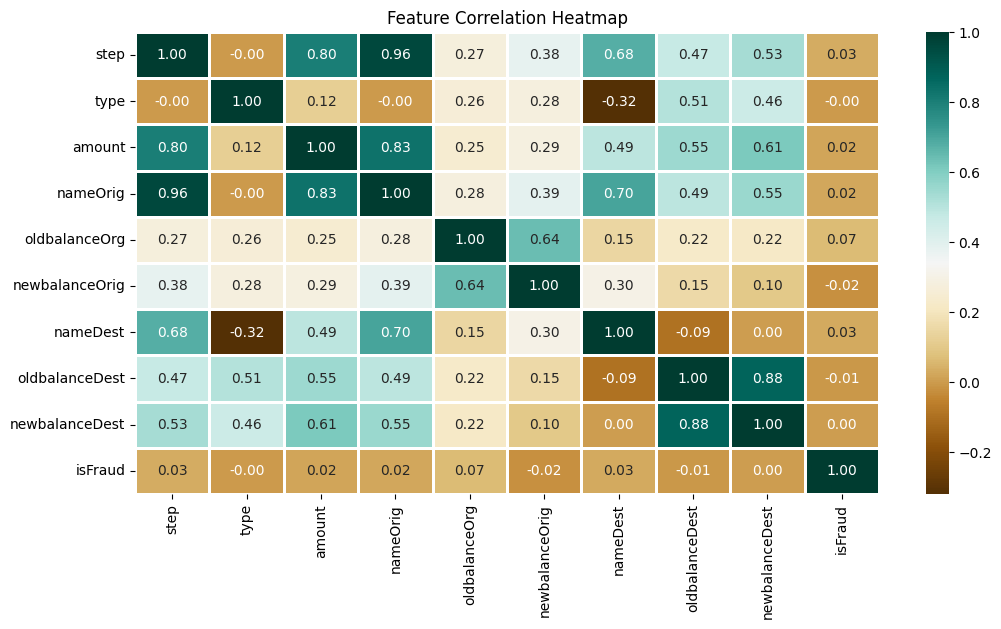

In [5]:
# data visualization 

# transaction type distribution 
plt.figure(figsize=(8,4))
sns.countplot(x='type',data=data_set)
plt.title('Transaction Type Count')
plt.show()

# Amount by transaction type
plt.figure(figsize=(8, 4))
sns.barplot(x='type', y='amount', data=data_set)
plt.title('Average Amount per Transaction Type')
plt.show()

# Fraud vs Non-Fraud count
plt.figure(figsize=(5, 4))
sns.countplot(x='isFraud', data=data_set)
plt.title('Fraud vs Non-Fraud')
plt.show()

# Step distribution
plt.figure(figsize=(15, 6))
sns.histplot(data_set['step'], bins=50)
plt.title('Transaction Step Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data_set.apply(lambda x: pd.factorize(x)[0]).corr(),
            cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
# Data Preprocessing
# encoding the 'type' column
type_encoded = pd.get_dummies(data_set['type'],drop_first=True)
data_new = pd.concat([data_set,type_encoded],axis=1)

# define features and target
x = data_new.drop(['isFraud','type','nameOrig','nameDest'],axis=1)
y = data_new['isFraud']

print("Feature shape:", x.shape)
print("Target shape:", y.shape)
print("Fraud cases:", (y==1).sum)
print("Non-fraud cases:", (y==0).sum())

Feature shape: (6362620, 10)
Target shape: (6362620,)
Fraud cases: <bound method Series.sum of 0          False
1          False
2           True
3           True
4          False
           ...  
6362615     True
6362616     True
6362617     True
6362618     True
6362619     True
Name: isFraud, Length: 6362620, dtype: bool>
Non-fraud cases: 6354407


In [7]:
# Handle class imbalance with smote 
# split first , then apply SMOTE only on training data 
x_train , x_test , y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

print("Before SMOTE:")
print("Fraud in train:",y_train.sum())
print("Non-fraud in train:",(y_train==0).sum())

# apply SMOTE 
smote = SMOTE(random_state=42)
x_train_sm,y_train_sm = smote.fit_resample(x_train,y_train)

print("\nAfter SMOTE:")
print("Fraud in train:",y_train_sm.sum())
print("Non-fraud in train:",(y_train_sm==0).sum())

Before SMOTE:
Fraud in train: 5778
Non-fraud in train: 4448056

After SMOTE:
Fraud in train: 4448056
Non-fraud in train: 4448056


In [8]:
# train Models 
models = [
    LogisticRegression(max_iter=1000),
    XGBClassifier(random_state=42, eval_metric='logloss'),
    RandomForestClassifier(n_estimators=7,criterion='entropy',random_state=7)
]

model_name = ['Logistic Regression', 'XGBoost', 'Random Forest'] 

for i , model in enumerate(models) : 
    model.fit(x_train_sm , y_train_sm )
    print(f'{model_name}:') 

    train_preds = model.predict_proba(x_train_sm)[:,1] 
    print('  Training ROC-AUC:', round(roc_auc_score(y_train_sm,train_preds),4))

    test_preds = model.predict_proba(x_test)[:,1]
    print('  Validation ROC-AUC:', round(roc_auc_score(y_test,test_preds), 4))
    print()

['Logistic Regression', 'XGBoost', 'Random Forest']:
  Training ROC-AUC: 0.9892
  Validation ROC-AUC: 0.9847

['Logistic Regression', 'XGBoost', 'Random Forest']:
  Training ROC-AUC: 1.0
  Validation ROC-AUC: 0.9988

['Logistic Regression', 'XGBoost', 'Random Forest']:
  Training ROC-AUC: 1.0
  Validation ROC-AUC: 0.9937



<Figure size 600x400 with 0 Axes>

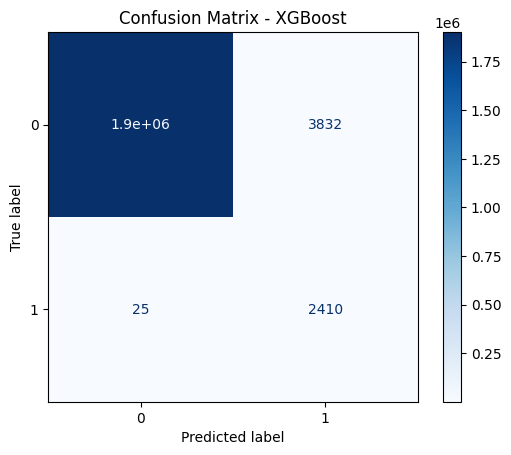

In [9]:
# Confusion Matrix(XGBoost)
plt.figure(figsize=(6,4))
cm = ConfusionMatrixDisplay.from_estimator(models[1], x_test,y_test, cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()

C:\Users\my pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


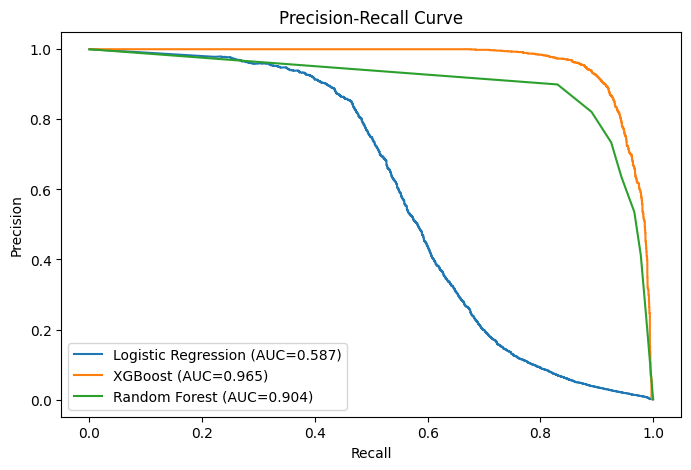

In [10]:
# precision-Recall Curve 
plt.figure(figsize=(8,5))

for i, model in enumerate(models): 
    y_probs = model.predict_proba(x_test)[:,1]
    precision , recall , _ = precision_recall_curve(y_test,y_probs) 
    pr_auc = auc(recall,precision )
    plt.plot(recall, precision , label=f'{model_name[i]} (AUC={pr_auc:.3f})')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

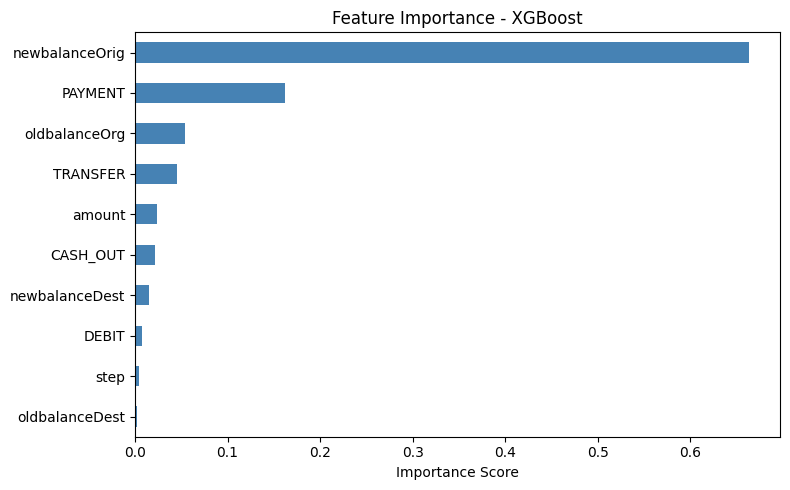

In [12]:
# Feature Importance (XGBoost)
feat_importances = pd.Series(
    models[1].feature_importances_, index = x.columns)

plt.figure(figsize = (8,5))
feat_importances.sort_values().plot(kind='barh',color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()